In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os 
from pathlib import Path
import torch 

import m2aia as m2
from ims_contrastive_model import IMSPyTorchDataset, IMSContrastiveModel 

# seting global dir
cwd=Path.cwd()
if cwd.name == "tutorials":
    # os.chdir(cwd.parent.parent) 
    os.chdir(cwd.parent) 
os.getcwd()

'/home/maxi7524/repositories/pym2aia_test'

In [2]:
# data loading 
PATH_DATA = Path('data')
PATH_sim_data = PATH_DATA / 'simulation_data' / 'test_4_final.imzML'
print(PATH_sim_data.exists())
PATH_real_data = PATH_DATA / 'bladder_data' / 'mouse_bladder.imzML'
print(PATH_real_data.exists())

# load data - IMPORTANT (NEED TO PASS STR)
reader_real = m2.ImzMLReader(str(PATH_real_data))

True
True
!Wed Apr 22 22:08:03 2026 
4.812! WARNING: No pixel size found, set x and y spacing to 50 microns!
!7.493! WARNING: Processed profile spectrum is not fully supported! Check the ImzML file.
[8.158] [imzML]: data/bladder_data/mouse_bladder.imzML
	[pixel size (mm)]: 0.050000x0.050000x0.010000
	[image dimension]: 260x134x1
	[num spectra]: 34840
	[spec. type]: ProcessedProfile
	[mass range]: 400.259620 to 999.795899 with #1500 measurements


In [14]:
dataset = IMSPyTorchDataset(reader_real, PATH_real_data.with_suffix(''))
model = IMSContrastiveModel(dataset, 64, epochs=20)

In [15]:
model.load(PATH_real_data.with_suffix(''))

[Load]: Model loaded from data/bladder_data/mouse_bladder
[Load]: Model loaded successfully from data/bladder_data/mouse_bladder


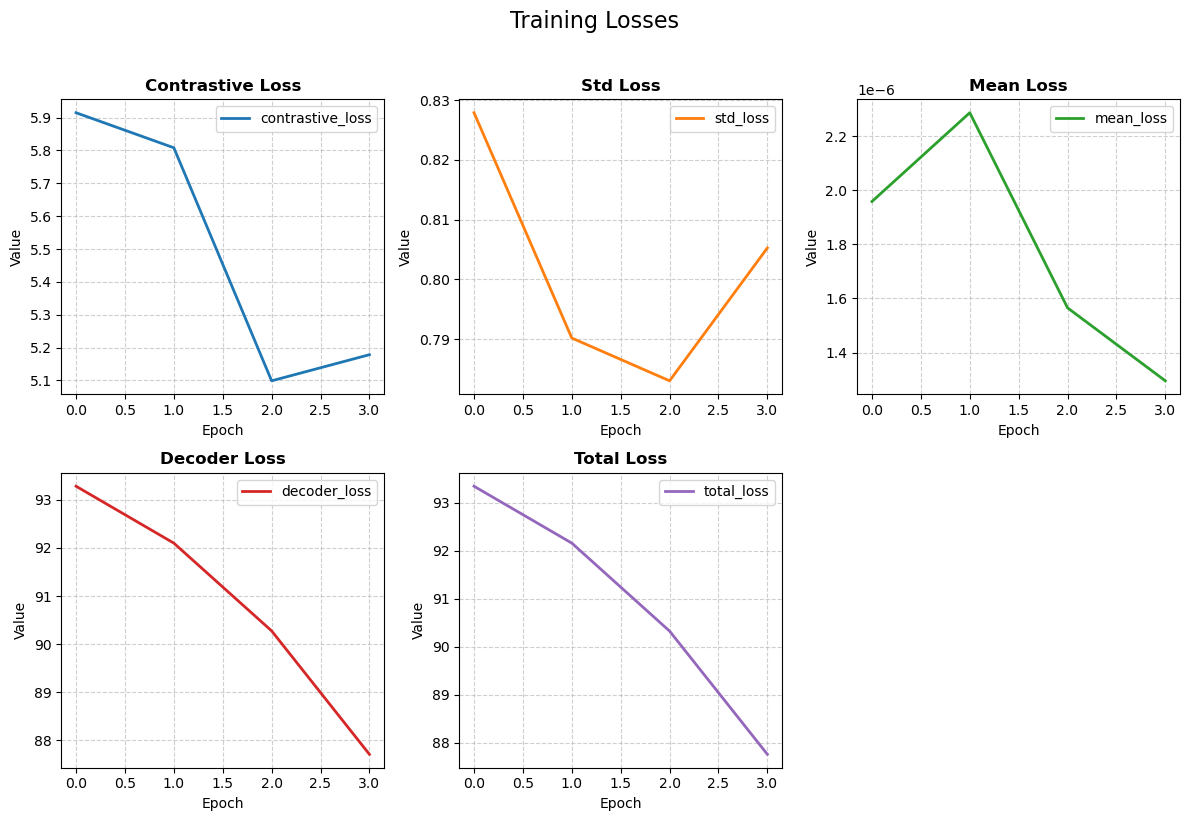

In [5]:
model.plot_epoch_losses()

In [6]:
model._batch_size = 128
model._epochs = 20
model.fit(Loader.data_path)

[fit]: Continue training on loaded model ...
[save]: Model is saved
Epoch 1/20 | Loss: 84.8711 | Patience: 0/5
[save]: Model is saved
Epoch 2/20 | Loss: 82.5730 | Patience: 0/5
[save]: Model is saved
Epoch 3/20 | Loss: 81.8070 | Patience: 0/5
[save]: Model is saved
Epoch 4/20 | Loss: 81.2599 | Patience: 0/5
[save]: Model is saved
Epoch 5/20 | Loss: 78.9508 | Patience: 0/5
[save]: Model is saved
Epoch 6/20 | Loss: 76.7760 | Patience: 0/5
[save]: Model is saved
Epoch 7/20 | Loss: 76.1019 | Patience: 0/5
[save]: Model is saved
Epoch 8/20 | Loss: 75.4868 | Patience: 0/5
[save]: Model is saved
Epoch 9/20 | Loss: 73.6794 | Patience: 0/5
[save]: Model is saved
Epoch 10/20 | Loss: 71.8528 | Patience: 0/5
[save]: Model is saved
Epoch 11/20 | Loss: 71.2735 | Patience: 0/5
[save]: Model is saved
Epoch 12/20 | Loss: 70.8393 | Patience: 0/5
[save]: Model is saved
Epoch 13/20 | Loss: 69.1244 | Patience: 0/5
[save]: Model is saved
Epoch 14/20 | Loss: 67.3738 | Patience: 0/5
[save]: Model is saved
Epo

In [8]:
latent_space = model.transform()

[Model] Encoding image to latent space...


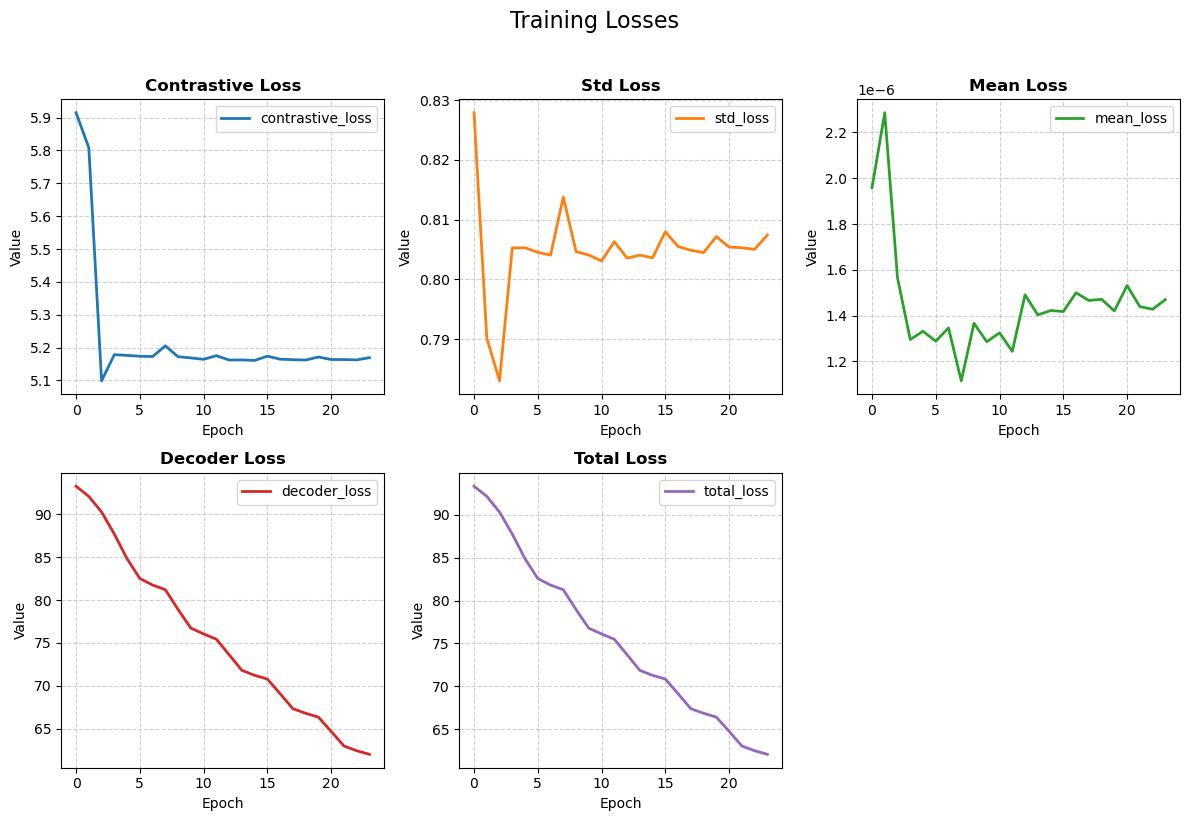

In [7]:
model.plot_epoch_losses()

In [8]:
model.model

ContrastiveAutoencoder(
  (encoder): Encoder(
    (layers): ModuleList(
      (0): Sequential(
        (0): Conv1d(1, 2, kernel_size=(7,), stride=(2,))
        (1): LayerNorm((29975,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
      )
      (1): Sequential(
        (0): Conv1d(2, 4, kernel_size=(7,), stride=(3,))
        (1): LayerNorm((9990,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
      )
      (2): Sequential(
        (0): Conv1d(4, 16, kernel_size=(5,), stride=(3,))
        (1): LayerNorm((3329,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
      )
      (3): Sequential(
        (0): Conv1d(16, 32, kernel_size=(5,), stride=(3,))
        (1): LayerNorm((1109,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
      )
      (4): Sequential(
        (0): Conv1d(32, 64, kernel_size=(5,), stride=(3,))
        (1): LayerNorm((369,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
      )
    )
    (flatten): Flatten(start_dim=1, e

In [27]:
next(dataloader)

tensor([[0., 0., 0.,  ..., 0., 0., 0.]])

In [38]:
from torchview import draw_graph
from torch.utils.data import DataLoader

dataloader = iter(DataLoader(dataset, batch_size=1, shuffle=True, num_workers=2))


batch_size = 1
model_graph = draw_graph(model.model, input_size=next(dataloader).shape, expand_nested=False, depth=2,show_shapes=True, graph_attr={'rankdir': 'LR'})

model_graph.visual_graph.render("model_architecture", format="png")

RuntimeError: Failed to run torchgraph see error message

In [41]:
from torchview import draw_graph
from torch.utils.data import DataLoader

# 1. Pobieramy batch i wyciągamy tylko dane (x)
batch = next(iter(DataLoader(dataset, batch_size=1, shuffle=True)))
x = batch 

# 2. Generujemy graf bez problematycznego 'graph_attr'
model_graph = draw_graph(
    model.model, 
    input_data=x,           # Używamy danych, to bezpieczniejsze niż input_size
    expand_nested=False, 
    depth=2,
    show_shapes=True
)

# 3. Jeśli CHCESZ zmienić kierunek na poziomy, robimy to tutaj:
model_graph.visual_graph.graph_attr.update(rankdir='LR')

# 4. Zapisujemy
# model_graph.visual_graph.render("model_architecture", format="png")

In [42]:
model_graph.visual_graph